# Read H-Reflex App Data Files

This notebook reads and visualizes data from the **H-Reflex Behavior App** (hreflex_txbdc) binary data files.

**V2 file convention (current):**
- **`.hrs1`**  MH Recruitment Curve stage: sweeps across stimulation intensities to map the M/H-wave recruitment curve.
- **`.hrs2`**  Control Mode stage: stimulates at a fixed user-set intensity (can be changed between trials).
- **`.hrs3`**  Down Condition Pellet (DCP) stage: closed-loop H-reflex conditioning with pellet reward.

**V1 file convention (legacy):**
- **`.hrs1`**  EMG Characterization stage: captures baseline EMG grand-mean distribution.
- **`.hrs2`**  MH Recruitment Curve stage (same binary format as V2 `.hrs1`).

All trial files share the MhRecHeader + MhRecTrial binary format.
EMG data blocks (raw differential, filtered, abs-value) are embedded in every file.

The binary format is based on the `FileIO_Helpers` serialization from the `hreflex_txbdc` package.

# Section 1: Binary File Reader Utilities

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from helpers import (
    # File readers
    read_hrs1, read_hrs2, read_hrs3, read_hrs4, read_hrs5, read_hrs6, read_hrs_ft,
    find_hrs_files, detect_app_version,
    # Summary printers
    print_hrs1_summary, print_hrs2_summary,
    # HRS2 plots
    plot_amplitude_distribution, plot_background_emg_views, plot_hrs2_analysis,
    plot_actual_trial_timeline, plot_mwave_control_error, plot_frequency_test,
    # SNR analysis
    compute_snr_analysis, compute_mra_snr_analysis,
    plot_hrs2_trials, classify_trials, get_trial_window,
    detect_stim_onset, get_trial_context_window,
    detect_and_correct_failed_trials,
    # Post-hoc global windowing analysis
    analyze_global_background, run_threshold_sweep, plot_threshold_sweep,
    split_trials_by_polarity, plot_hm_ratio_summary, plot_hwave_regression,
    # Constants
    SAMPLE_RATE, BIN_DURATION_MS, BIN_SAMPLES, TRIAL_RECORD_MS,
    STIM_ONSET_THRESHOLD, STIM_END_THRESHOLD,
    build_merged_amp_groups,
)

print("Helpers loaded.")
print(f"  App constants: SAMPLE_RATE={SAMPLE_RATE} Hz | BIN={BIN_DURATION_MS} ms ({BIN_SAMPLES} samples) | TRIAL_RECORD={TRIAL_RECORD_MS} ms")
print(f"  Stim thresholds: onset >= {STIM_ONSET_THRESHOLD} V | end < {STIM_END_THRESHOLD} V")

Helpers loaded.
  App constants: SAMPLE_RATE=5000.0 Hz | BIN=50 ms (250 samples) | TRIAL_RECORD=100 ms
  Stim thresholds: onset >= 4.5 V | end < 1.9 V


# Section 2: HRS1 File EMG Characterization (V1 only)

The cells in this section apply only to **V1** recordings where `.hrs1` contains
the EMG Characterization stage. They are automatically skipped for V2 recordings.

# Section 1b: Auto-Detect Recording Files

Set `recording_dir` to the path of your recording folder.  
The `.hrs1` and `.hrs2` files will be found automatically.

In [2]:
# "HRPilot-18_Control/CC1_HRPILOT-18_BOOTH1_500US_6-29-26"
# "HRPilot-18_Control/CC3_HRPILOT-18_BOOTH1_500US_7-6-26"
# "HRPilot-18_Control/CC5_HRPILOT-18_BOOTH1_500US_7-8-26"
# "HRPilot-18_Control/CC6_HRPILOT-18_BOOTH1_500US_7-9-26"
# "HRPilot-18_Control/HRPILOT-18_M-WAVE_ALGORITHM_TEST_BOOTH1_7-16-26"
# "HRPilot-18_Control/HRPILOT-18_CONTROL1_BOOTH2_250US_10KHZ_7-17-26"
# "HRPilot-18_Control/HRPILOT-18_CONTROL3_BOOTH2_250US_10KHZ_7-21-26"
# "HRPilot-18_Control/HRPILOT-18_CONTROL4_BOOTH2_250US_10KHZ_7-22-26"

recording_dir         = "HRPilot-18_Control/HRPILOT-18_CONTROL4_BOOTH2_250US_10KHZ_7-22-26"
recording_sample_rate = 10000  # Set to e.g. 5000.0 or 10000.0 to override; None = auto-detect

hrs1_path, hrs2_path, hrs3_path, hrs4_path, hrs5_path, hrs6_path, hrsft_path = find_hrs_files(recording_dir)
_app_version = detect_app_version(recording_dir)
print(f"H-Reflex App V{_app_version}  |  "
      f"hrs1={os.path.basename(hrs1_path)  if hrs1_path  else chr(8211)}  "
      f"hrs2={os.path.basename(hrs2_path)  if hrs2_path  else chr(8211)}  "
      f"hrs3={os.path.basename(hrs3_path)  if hrs3_path  else chr(8211)}  "
      f"hrs4={os.path.basename(hrs4_path)  if hrs4_path  else chr(8211)}  "
      f"hrs5={os.path.basename(hrs5_path)  if hrs5_path  else chr(8211)}  "
      f"hrs6={os.path.basename(hrs6_path)  if hrs6_path  else chr(8211)}  "
      f"hrsft={os.path.basename(hrsft_path) if hrsft_path else chr(8211)}")

H-Reflex App V3  |  hrs1=–  hrs2=HRPILOT-18_CONTROL4_BOOTH2_250US_10KHZ_7-22-26_20260722T100048.hrs2  hrs3=–  hrs4=–  hrs5=–  hrs6=–  hrsft=–


In [3]:
# --- Load all data files (auto-detects V1 / V2 / V3 app) ----------------------
cm_header  = cm_trials  = cm_emg_blocks  = None   # V2/V3 Control Mode
dcp_header = dcp_trials = dcp_emg_blocks = None   # V2/V3 Down Condition Pellet
s4_header  = s4_trials  = s4_emg_blocks  = None   # V3 Up Condition Pellet  (.hrs4)
s5_header  = s5_trials  = s5_emg_blocks  = None   # V3 Down Condition VNS   (.hrs5)
s6_header  = s6_trials  = s6_emg_blocks  = None   # V3 Up Condition VNS     (.hrs6)
ft_header  = ft_trials  = ft_emg_blocks  = None   # V3 Frequency Test       (.hrsft)

if _app_version == 1:
    if hrs1_path:
        hrs1_header, hrs1_trials, hrs1_emg_blocks = read_hrs1(hrs1_path)
        print_hrs1_summary(hrs1_header, hrs1_trials, hrs1_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — EMG Characterization data unavailable.")
        hrs1_header, hrs1_trials, hrs1_emg_blocks = None, [], []
    if hrs2_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs2_path)
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs2_path)
    else:
        print("No .hrs2 file found — MH Recruitment data unavailable.")
        hrs2_header, hrs2_trials, hrs2_emg_blocks = None, [], []
else:
    # V2/V3: S1=MH Recruitment (.hrs1)  S2=Control Mode (.hrs2)  S3=DCP (.hrs3)
    #        V3 adds: S4 (.hrs4)  S5 (.hrs5)  S6 (.hrs6)  FT (.hrsft)
    if hrs1_path:
        hrs2_header, hrs2_trials, hrs2_emg_blocks = read_hrs2(hrs1_path)
        hrs1_header = hrs2_header
        hrs1_trials, hrs1_emg_blocks = [], []
        print_hrs2_summary(hrs2_header, hrs2_trials, hrs2_emg_blocks, hrs1_path)
    else:
        print("No .hrs1 file found — MH Recruitment data unavailable.")
        hrs1_header = hrs2_header = None
        hrs1_trials = hrs2_trials = []
        hrs1_emg_blocks = hrs2_emg_blocks = []
    if hrs2_path:
        cm_header, cm_trials, cm_emg_blocks = read_hrs2(hrs2_path)
        print(f"Control Mode:           {len(cm_trials)} trials")
    else:
        print("No .hrs2 file found — Control Mode data unavailable.")
    if hrs3_path:
        dcp_header, dcp_trials, dcp_emg_blocks = read_hrs3(hrs3_path)
        print(f"Down Condition Pellet:  {len(dcp_trials)} trials")
    else:
        print("No .hrs3 file found — Down Condition Pellet data unavailable.")
    if hrs4_path:
        s4_header, s4_trials, s4_emg_blocks = read_hrs4(hrs4_path)
        print(f"Up Condition Pellet:    {len(s4_trials)} trials")
    if hrs5_path:
        s5_header, s5_trials, s5_emg_blocks = read_hrs5(hrs5_path)
        print(f"Down Condition VNS:     {len(s5_trials)} trials")
    if hrs6_path:
        s6_header, s6_trials, s6_emg_blocks = read_hrs6(hrs6_path)
        print(f"Up Condition VNS:       {len(s6_trials)} trials")
    if hrsft_path:
        ft_header, ft_trials, ft_emg_blocks = read_hrs_ft(hrsft_path)
        print(f"Frequency Test:         {len(ft_trials)} trials")

# V2/V3 Control Mode-only: alias hrs2_trials ← cm_trials so downstream cells work.
if _app_version in (2, 3) and not hrs2_trials and cm_trials:
    hrs2_header     = cm_header
    hrs2_trials     = cm_trials
    hrs2_emg_blocks = cm_emg_blocks
    hrs1_header     = hrs2_header
    print("Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).")

if hrs1_header is None:
    class _SampleRateStub:
        sample_rate = recording_sample_rate or 5000.0
    hrs1_header = _SampleRateStub()

No .hrs1 file found — MH Recruitment data unavailable.
Control Mode:           724 trials
No .hrs3 file found — Down Condition Pellet data unavailable.
Note: Control Mode trials used as primary analysis (no Recruitment Curve stage).


In [ ]:
# V1 EMG Characterization plots  skipped for V2 recordings or when .hrs1 is absent.
if not hrs1_trials:
    print('No EMG Characterization stage data  skipping V1 EMG char plots.')
else:
    # ---- Plot HRS1: Trial Grand Means (Session History) ----
    grand_means = [t.grand_mean for t in hrs1_trials]
    
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(range(len(grand_means)), grand_means, 'o', color='blue', markersize=6)
    ax.set_xlabel('Trial Number')
    ax.set_ylabel('Grand Mean (uV)')
    ax.set_title(f'HRS1 Session History - {hrs1_header.subject_id} ({hrs1_header.session_datetime:%Y-%m-%d %H:%M})')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Grand mean range: [{min(grand_means):.2f}, {max(grand_means):.2f}] uV")
    print(f"Overall mean of grand means: {np.mean(grand_means):.2f} uV")
    
    # ---- Plot HRS1: Histogram of Grand Means ----
    gm = np.array(grand_means)
    
    fig, ax = plt.subplots(figsize=(10, 5))
    hist_vals, hist_edges, _ = ax.hist(gm, bins=50, color='steelblue', edgecolor='black', alpha=0.8)
    #ax.axvline(hrs1_header.trial_initiation_uv_min, color='red', linestyle='--', linewidth=1.5, label=f'Init min = {hrs1_header.trial_initiation_uv_min}')
    #ax.axvline(hrs1_header.trial_initiation_uv_max, color='red', linestyle='--', linewidth=1.5, label=f'Init max = {hrs1_header.trial_initiation_uv_max}')
    
    q25, q50, q75 = np.percentile(gm, [25, 50, 75])
    ax.axvline(q25, color='orange', linestyle=':', linewidth=1.5, label=f'Q1 = {q25:.2f}')
    ax.axvline(q50, color='purple', linestyle='-.', linewidth=1.5, label=f'Median = {q50:.2f}')
    ax.axvline(q75, color='orange', linestyle=':', linewidth=1.5, label=f'Q3 = {q75:.2f}')
    
    ax.set_xlabel('Grand Mean Amplitude (uV)')
    ax.set_ylabel('Count')
    ax.set_title(f'HRS1 Histogram of Trial Grand Means - {hrs1_header.subject_id} (n={len(gm)})')
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    print(f"Stats: min={gm.min():.2f}, Q1={q25:.2f}, median={q50:.2f}, Q3={q75:.2f}, max={gm.max():.2f}, std={gm.std():.2f}")
    
    # ---- Plot HRS1: Individual Trial Waveforms (first 6 trials) ----
    n_show = min(6, len(hrs1_trials))
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    axes = axes.flatten()
    
    for i in range(n_show):
        ax = axes[i]
        trial = hrs1_trials[i]
        sig = np.array(trial.monitored_signal)
        bins_arr = np.array(trial.bins)
        bin_sample_count = int((SAMPLE_RATE / 1000) * hrs1_header.bin_duration_ms)
    
        # Time axis in ms
        t_ms = np.arange(len(sig)) / SAMPLE_RATE * 1000.0
    
        # Plot monitored signal (abs EMG)
        ax.plot(t_ms, sig, color='black', linewidth=0.5, label='Monitored signal')
    
        # Plot bins
        bin_x = np.arange(len(bins_arr)) * hrs1_header.bin_duration_ms
        ax.plot(bin_x, bins_arr, color='red', linewidth=2, label='Bins')
    
        ax.set_title(f'Trial {i+1} | GM={trial.grand_mean:.2f} uV', fontsize=10)
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Amplitude (uV)')
        ax.grid(True, alpha=0.3)
    
        if i == 0:
            ax.legend(fontsize=8)
    
    for j in range(n_show, len(axes)):
        axes[j].axis('off')
    
    fig.suptitle(f'HRS1 Trial Waveforms - {hrs1_header.subject_id}', fontsize=13)
    plt.tight_layout()
    plt.show()


No EMG Characterization stage data â€” skipping V1 EMG char plots.


# Section 3: Peri-Stimulus Trials â€” MH Recruitment Curve or Control Mode

For **V2** recordings `hrs2_trials` contains whichever stage was run:
- `.hrs1` present â†’ MH Recruitment Curve trials
- `.hrs1` absent, `.hrs2` present â†’ Control Mode trials (aliased automatically)

For **V1** recordings `hrs2_trials` contains the MH Recruitment Curve trials from `.hrs2`.

In [5]:
# Data already loaded in the cell above.
# hrs2_trials = MH Recruitment Curve trials (V1 or V2).
print(f"MH Recruitment trials : {len(hrs2_trials)}"
      + (f"  |  Control Mode: {len(cm_trials)}" if cm_trials  is not None else "")
      + (f"  |  DCP: {len(dcp_trials)}"         if dcp_trials is not None else ""))


MH Recruitment trials : 724  |  Control Mode: 724


Available stages:
  'control_mode'         → Control Mode (.hrs2)  (724 trials)  ◄ active

Active : Control Mode (.hrs2)  ·  724 trials
(Change ACTIVE_STAGE above + re-run this cell only when switching stages for Post-Hoc analysis.)

Histogram: Control Mode (.hrs2)  (724 trials)


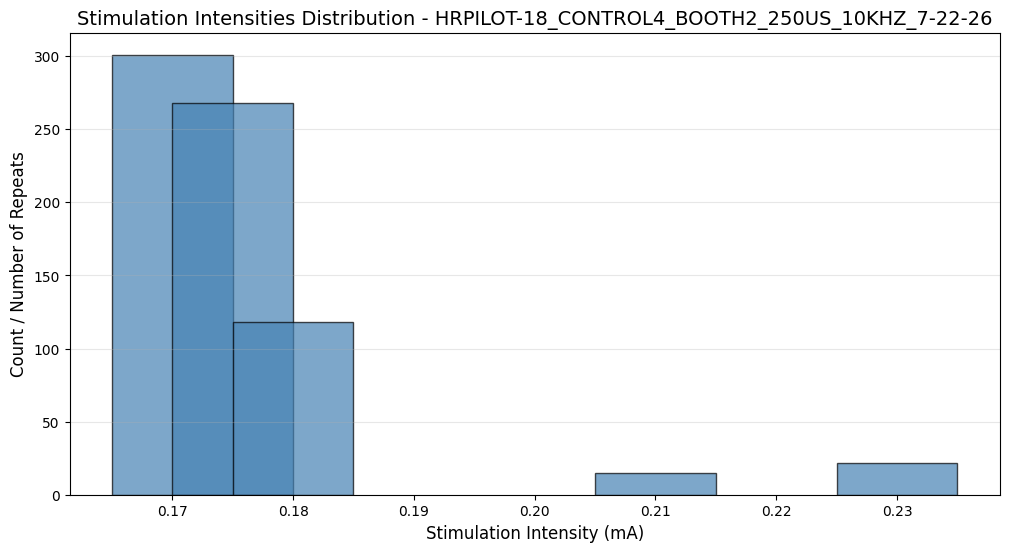

In [6]:
# ── Stage Selector + Stimulation Intensity Histogram ──────────────────────────
# ACTIVE_STAGE controls which stage the Post-Hoc notebook uses.
# All viewer cells show a Stage dropdown when multiple stages are loaded.

_stage_map = {}
if hrs2_trials and (not cm_trials or hrs2_trials is not cm_trials):
    _stage_map['mh_recruitment'] = (hrs2_trials, hrs2_header, hrs2_emg_blocks,
                                     'MH Recruitment Curve (.hrs1)')
if cm_trials:
    _stage_map['control_mode']   = (cm_trials,   cm_header,   cm_emg_blocks,
                                     'Control Mode (.hrs2)')
if dcp_trials:
    _stage_map['dcp']            = (dcp_trials,  dcp_header,  dcp_emg_blocks,
                                     'Down Condition Pellet (.hrs3)')
if s4_trials:
    _stage_map['up_cond_pellet'] = (s4_trials,   s4_header,   s4_emg_blocks,
                                     'Up Condition Pellet (.hrs4)')
if s5_trials:
    _stage_map['down_cond_vns']  = (s5_trials,   s5_header,   s5_emg_blocks,
                                     'Down Condition VNS (.hrs5)')
if s6_trials:
    _stage_map['up_cond_vns']    = (s6_trials,   s6_header,   s6_emg_blocks,
                                     'Up Condition VNS (.hrs6)')

ACTIVE_STAGE = next(iter(_stage_map))
# ACTIVE_STAGE = 'mh_recruitment'
# ACTIVE_STAGE = 'control_mode'
# ACTIVE_STAGE = 'dcp'
# ACTIVE_STAGE = 'up_cond_pellet'
# ACTIVE_STAGE = 'down_cond_vns'
# ACTIVE_STAGE = 'up_cond_vns'

if ACTIVE_STAGE not in _stage_map:
    ACTIVE_STAGE = next(iter(_stage_map))
    print(f'Note: requested stage not available; defaulting to {ACTIVE_STAGE!r}')

_sel = _stage_map[ACTIVE_STAGE]
_plot_trials, _plot_header, _plot_emg_blocks = _sel[0], _sel[1], _sel[2]

print('Available stages:')
for _k, (_t, _h, _e, _lbl) in _stage_map.items():
    _mark = '  ◄ active' if _k == ACTIVE_STAGE else ''
    print(f'  {_k!r:<22} → {_lbl}  ({len(_t)} trials){_mark}')
print(f'\nActive : {_sel[3]}  ·  {len(_plot_trials)} trials')
print('(Change ACTIVE_STAGE above + re-run this cell only when switching stages for Post-Hoc analysis.)')

# ── Stimulation Intensity Histogram ───────────────────────────────────────
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_hist_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_hist_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\nHistogram: {_slbl}  ({len(_st)} trials)')
    plot_amplitude_distribution(_st, _sh)
else:
    _hist_out  = Output()
    _hist_drop = Dropdown(options=_hist_opts, description='Stage:', layout={'width': '440px'})
    def _hist_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_hist_drop.value]
        with _hist_out:
            _hist_out.clear_output(wait=True)
            print(f'\nHistogram: {_slbl}  ({len(_st)} trials)')
            plot_amplitude_distribution(_st, _sh)
    _hist_drop.observe(_hist_show, names='value')
    _disp(VBox([_hist_drop, _hist_out]))
    _hist_show()


â”€â”€ Trial Timeline: Control Mode (.hrs2)  (724 trials)
Actual trial timeline (724 trials)
  Recording span : 14319.0 s  (3.978 h)
  Trial rate     : 182.0 trials / hour
  ITI — mean: 19805 ms  |  median: 5962 ms  |  min: 4943 ms  |  max: 587316 ms


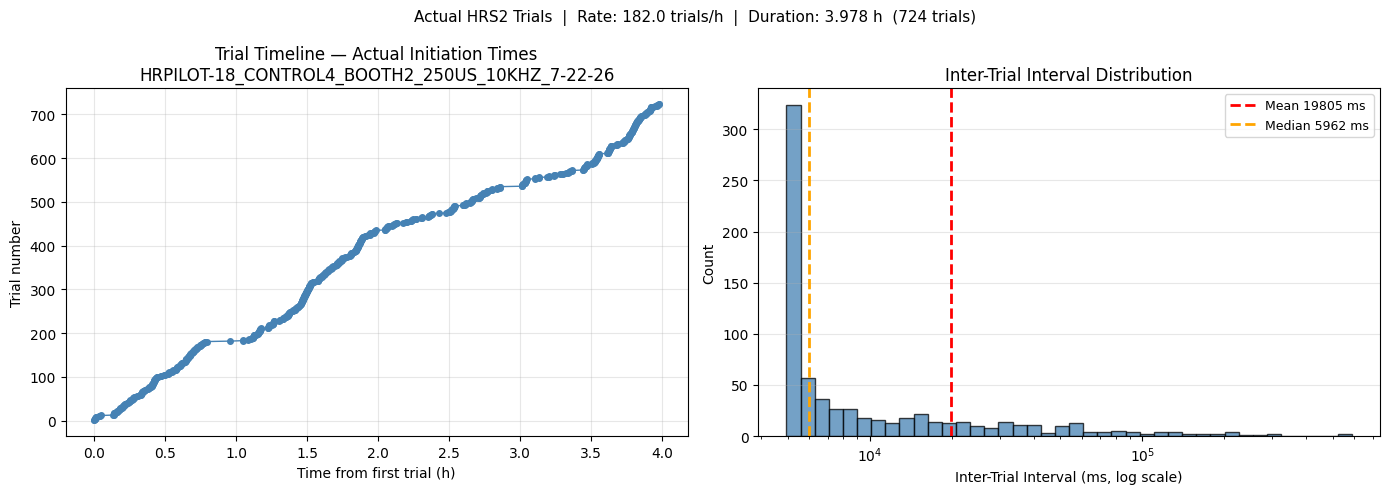

In [7]:
# Trial Timeline 
# # Shows trial number vs. actual wall-clock time and inter-trial interval (ITI)
# distribution for each recording stage.
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_tl_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_tl_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\nâ”€â”€ Trial Timeline: {_slbl}  ({len(_st)} trials)')
    plot_actual_trial_timeline(_st, header=_sh)
else:
    _tl_out  = Output()
    _tl_drop = Dropdown(options=_tl_opts, description='Stage:', layout={'width': '440px'})
    def _tl_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_tl_drop.value]
        with _tl_out:
            _tl_out.clear_output(wait=True)
            print(f'\nâ”€â”€ Trial Timeline: {_slbl}  ({len(_st)} trials)')
            plot_actual_trial_timeline(_st, header=_sh)
    _tl_drop.observe(_tl_show, names='value')
    _disp(VBox([_tl_drop, _tl_out]))
    _tl_show()


# Section 3a: Initiation Thresholds Summary

Displays the EMG amplitude thresholds and timing windows used to initiate trials in both stages:

- **S1 (EMG Characterization):** fixed thresholds stored in the file header Ã¢â‚¬â€ the grand mean of binned absolute EMG must fall between `trial_initiation_uv_min` and `trial_initiation_uv_max`.
- **S2 (MH Recruitment Curve):** per-trial thresholds stored with each trial Ã¢â‚¬â€ the app derives them from the S1 histogram percentiles, so they may vary if the experimenter re-ran the calculation.

In [8]:
# ---- Initiation Thresholds Summary ----

print("=" * 62)
print("  INITIATION THRESHOLDS SUMMARY")
print("=" * 62)

# --- S1: EMG Characterization (values stored in HRS1 header) ---
print("\nS1 EMG Characterization Stage")
if hasattr(hrs1_header, 'trial_initiation_uv_min'):
    print(f"  Lower bound : {hrs1_header.trial_initiation_uv_min:.2f} µV")
    print(f"  Upper bound : {hrs1_header.trial_initiation_uv_max:.2f} µV")
    print(f"  (A trial is accepted when the grand mean of binned |EMG| falls within this range)")
    print(f"  Monitoring window : {hrs1_header.trial_initiation_phase_min_ms}–{hrs1_header.trial_initiation_phase_max_ms} ms  |  Bin duration : {hrs1_header.bin_duration_ms} ms")
else:
    print("  (No EMG Characterization stage — V2 recording or V1 without .hrs1 file)")

# --- S2: MH Recruitment Curve (lower/upper bounds stored per trial in HRS2) ---
print("\nS2 MH Recruitment Curve Stage")
if _plot_header is None or len(_plot_trials) == 0:
    print("  No HRS2 file / no trials found.")
else:
    s2_mins = [t.min_initiation_threshold for t in _plot_trials]
    s2_maxs = [t.max_initiation_threshold for t in _plot_trials]
    all_same = (len(set(round(v, 4) for v in s2_mins)) == 1 and
                len(set(round(v, 4) for v in s2_maxs)) == 1)
    if all_same:
        print(f"  Lower bound : {s2_mins[0]:.4f} µV  (constant across all {len(_plot_trials)} trials)")
        print(f"  Upper bound : {s2_maxs[0]:.4f} µV  (constant across all {len(_plot_trials)} trials)")
    else:
        print(f"  Thresholds varied across {len(_plot_trials)} trials:")
        print(f"  {'Trial':>6}  {'Lower bound (µV)':>18}  {'Upper bound (µV)':>18}")
        for i, (mn, mx) in enumerate(zip(s2_mins, s2_maxs)):
            print(f"  {i + 1:>6}  {mn:>18.4f}  {mx:>18.4f}")

print("\n" + "=" * 62)

  INITIATION THRESHOLDS SUMMARY

S1 EMG Characterization Stage
  (No EMG Characterization stage — V2 recording or V1 without .hrs1 file)

S2 MH Recruitment Curve Stage
  Lower bound : 275.0000 µV  (constant across all 724 trials)
  Upper bound : 550.0000 µV  (constant across all 724 trials)



In [9]:
shared_ylim = (-1500, 1500)  # Set a common y-axis limit for all trial plots

In [10]:
#  Configuration 
PRE_PLOT_MS  = 2   # ms before stim onset to display
POST_PLOT_MS = 15  # ms after  stim onset to display
N_PER_PAGE   = 6   # trials shown per page (2 rows x 3 cols)

# M/H wave window constants (ms relative to stim onset)
M_WAVE_START_MS = 1.8 
M_WAVE_END_MS   = 5
H_WAVE_START_MS = 6.5
H_WAVE_END_MS   = 9

PRE_AVG_MS  = 2   # ms before stim onset
POST_AVG_MS = 15  # ms after  stim onset
N_PER_PAGE  = 6   # amplitude groups per page (2 rows x 3 cols)


In [11]:
'''# ---- Failed Trial Detector & Corrected Trial Windowing ----
# Classifies all trials for ADC-sync failures, realigns each failed trial to the
# true stim onset found via the first ADC pulse in the continuous context window,
# and plots original (gray) vs corrected (black) waveforms.
# Returns trial_report, failed, passed, realigned for use in later cells.
trial_report, failed, passed, realigned = detect_and_correct_failed_trials(
    _plot_trials, _plot_header, _plot_emg_blocks,
    pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
    sample_rate=recording_sample_rate or hrs1_header.sample_rate,
)'''

'# ---- Failed Trial Detector & Corrected Trial Windowing ----\n# Classifies all trials for ADC-sync failures, realigns each failed trial to the\n# true stim onset found via the first ADC pulse in the continuous context window,\n# and plots original (gray) vs corrected (black) waveforms.\n# Returns trial_report, failed, passed, realigned for use in later cells.\ntrial_report, failed, passed, realigned = detect_and_correct_failed_trials(\n    _plot_trials, _plot_header, _plot_emg_blocks,\n    pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,\n    m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,\n    h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,\n    sample_rate=recording_sample_rate or hrs1_header.sample_rate,\n)'

In [12]:
# ── Optional: Merged Amplitude Group Analysis ─────────────────────────────
# MERGE_ALL = True  →  collapse every amplitude into a single group.
#
# MERGED_GROUPS accepts two styles (mix freely):
#   Explicit list : [0.12, 0.13, 0.15]   — merge exactly those amplitudes
#   Range tuple   : (0.10, 0.50)         — merge all amplitudes where low <= amp <= high
#
# Examples:
#   MERGED_GROUPS = [[0.12, 0.13], [0.15, 0.16, 0.17]]   ← two explicit groups
#   MERGED_GROUPS = [(0.10, 0.20), (0.25, 0.40)]          ← two range groups
#   MERGED_GROUPS = [(0.10, 0.20), [0.50, 0.55]]          ← range + explicit, mixed
#
# Leave both flags at their defaults to use the standard (unmerged) grouping.
MERGE_ALL     = True   # True → collapse every amplitude into one group
MERGED_GROUPS = []

def _resolve_groups(trials, groups):
    _all_amps = sorted({t.stimulation_amplitude_ma for t in trials})
    resolved = []
    for g in groups:
        if isinstance(g, tuple) and len(g) == 2:
            lo, hi = float(g[0]), float(g[1])
            matched = [a for a in _all_amps if lo <= a <= hi]
            if matched:
                resolved.append(matched)
            else:
                print(f'Warning: range ({lo}, {hi}) matched no amplitudes — skipped.')
        else:
            resolved.append(list(g))
    return resolved

def _apply_merge(trials):
    if MERGE_ALL:
        _amps = sorted({t.stimulation_amplitude_ma for t in trials})
        return build_merged_amp_groups(trials, [_amps])
    if MERGED_GROUPS:
        return build_merged_amp_groups(trials, _resolve_groups(trials, MERGED_GROUPS))
    return trials

_hrs2_trials_plot = _apply_merge(_plot_trials)


Merged group ['0.170', '0.175', '0.180', '0.210', '0.230'] mA -> avg 0.193 mA, 724 trials


In [ ]:

# ----- Failed Trial Detector  and Corrected Trial Windowing  Here----

#  HRS2 Analysis: Interactive Averaged Waveforms + Recruitment Curve â”€â”€â”€â”€â”€
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_ana_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_ana_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    _tp = _apply_merge(_st)
    print(f'\nAnalysis: {_slbl}  ({len(_st)} trials)')
    plot_hrs2_analysis(
        _tp, _sh,
        pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
        n_per_page=N_PER_PAGE,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        emg_blocks=_se,
    )
else:
    _ana_out  = Output()
    _ana_drop = Dropdown(options=_ana_opts, description='Stage:', layout={'width': '440px'})
    def _ana_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_ana_drop.value]
        _tp = _apply_merge(_st)
        with _ana_out:
            _ana_out.clear_output(wait=True)
            print(f'\nâ”€â”€ Analysis: {_slbl}  ({len(_st)} trials)')
            plot_hrs2_analysis(
                _tp, _sh,
                pre_avg_ms=PRE_AVG_MS, post_avg_ms=POST_AVG_MS,
                n_per_page=N_PER_PAGE,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                emg_blocks=_se,
            )
    _ana_drop.observe(_ana_show, names='value')
    _disp(VBox([_ana_drop, _ana_out]))
    _ana_show()


Merged group ['0.170', '0.175', '0.180', '0.210', '0.230'] mA -> avg 0.193 mA, 724 trials

â”€â”€ Analysis: Control Mode (.hrs2)  (724 trials)
Loaded 1 amplitude groups across 1 page(s).
Double-click a subplot to zoom in. Ctrl-click to select multiple signals.


Output()

c:\Users\dal866445\Documents\Github\open-ephys-python-tools\.venv\Lib\site-packages\scipy\interpolate\_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


HTML(value='<hr><b>Background EMG — selected amplitude / polarity group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected amplitude / polarity group</b>')

Output()

In [14]:
# â”€â”€ HRS2 Trial Viewer: Interactive Per-Trial Grid + Zoom â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_trv_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_trv_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    _tp = _apply_merge(_st)
    print(f'\nâ”€â”€ Trial Viewer: {_slbl}  ({len(_st)} trials)')
    plot_hrs2_trials(
        _tp, _sh,
        pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
        n_per_page=N_PER_PAGE,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        emg_blocks=_se,
    )
else:
    _trv_out  = Output()
    _trv_drop = Dropdown(options=_trv_opts, description='Stage:', layout={'width': '440px'})
    def _trv_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_trv_drop.value]
        _tp = _apply_merge(_st)
        with _trv_out:
            _trv_out.clear_output(wait=True)
            print(f'\nâ”€â”€ Trial Viewer: {_slbl}  ({len(_st)} trials)')
            plot_hrs2_trials(
                _tp, _sh,
                pre_plot_ms=PRE_PLOT_MS, post_plot_ms=POST_PLOT_MS,
                n_per_page=N_PER_PAGE,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                emg_blocks=_se,
            )
    _trv_drop.observe(_trv_show, names='value')
    _disp(VBox([_trv_drop, _trv_out]))
    _trv_show()


Merged group ['0.170', '0.175', '0.180', '0.210', '0.230'] mA -> avg 0.193 mA, 724 trials

â”€â”€ Trial Viewer: Control Mode (.hrs2)  (724 trials)
Loaded 724 trials across 121 page(s).
Sample rate: 10000 Hz  |  ms/sample: 0.1000
Stim waveform: available
Double-click a subplot to zoom in, or use the dropdown + 'View trial' button.


HTML(value='<hr><b>Background EMG — selected group</b>')

Output()

HTML(value='<hr><b>H:M Ratio Summary — selected group</b>')

Output()

HTML(value='<hr><b>H-wave Regression — selected group</b>')

Output()

# Section 3c: H:M Ratio Summary

Box plot and histogram of H:M ratio for each stimulation polarity group.
If both normal and reversed polarities were used in this session, each group is analysed separately.


â”€â”€ Polarity / H:M Ratio: Control Mode (.hrs2)  (724 trials)


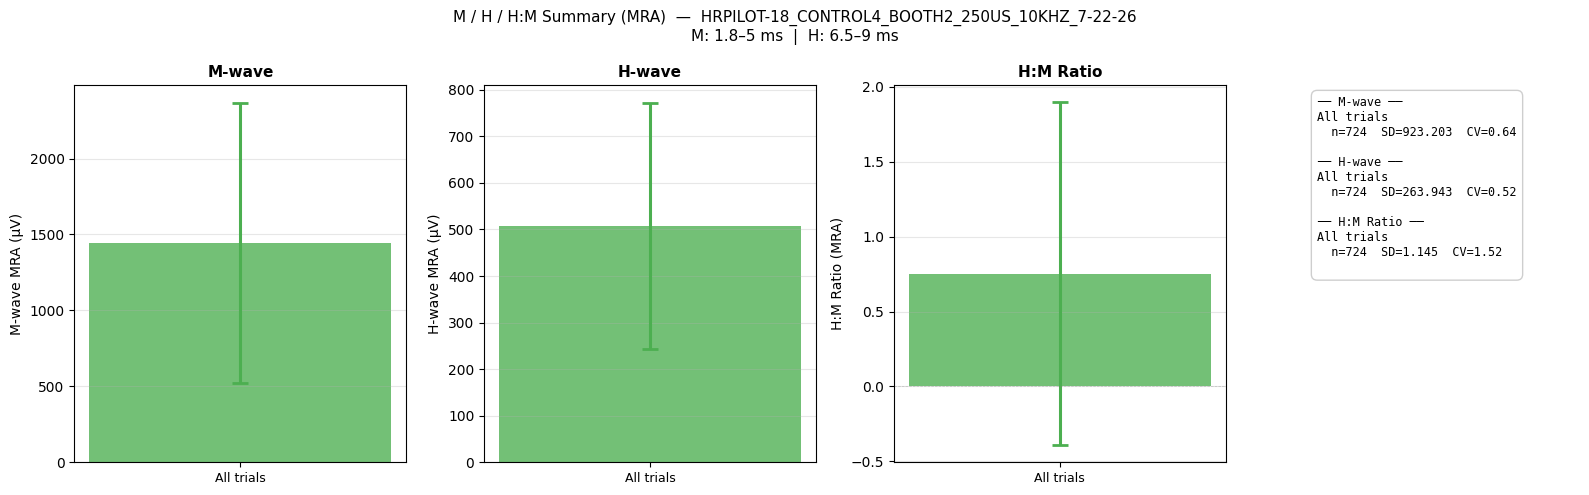

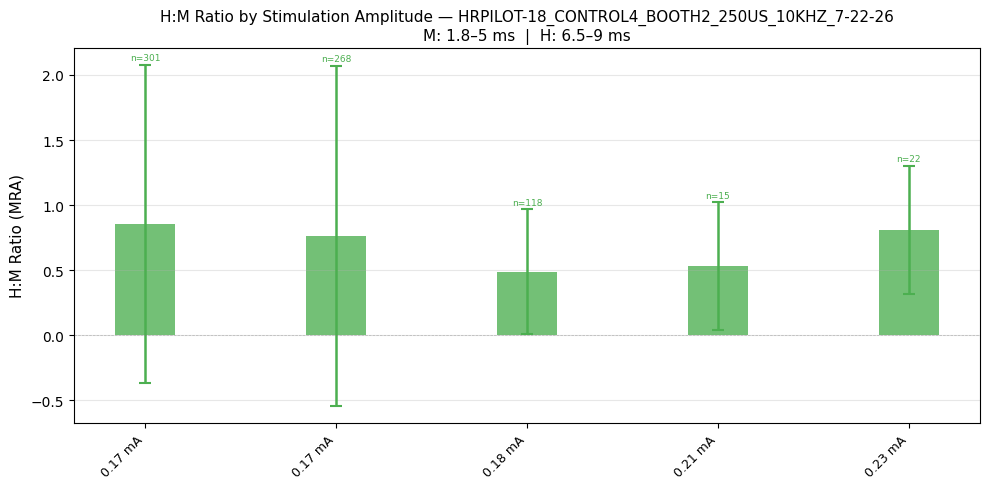

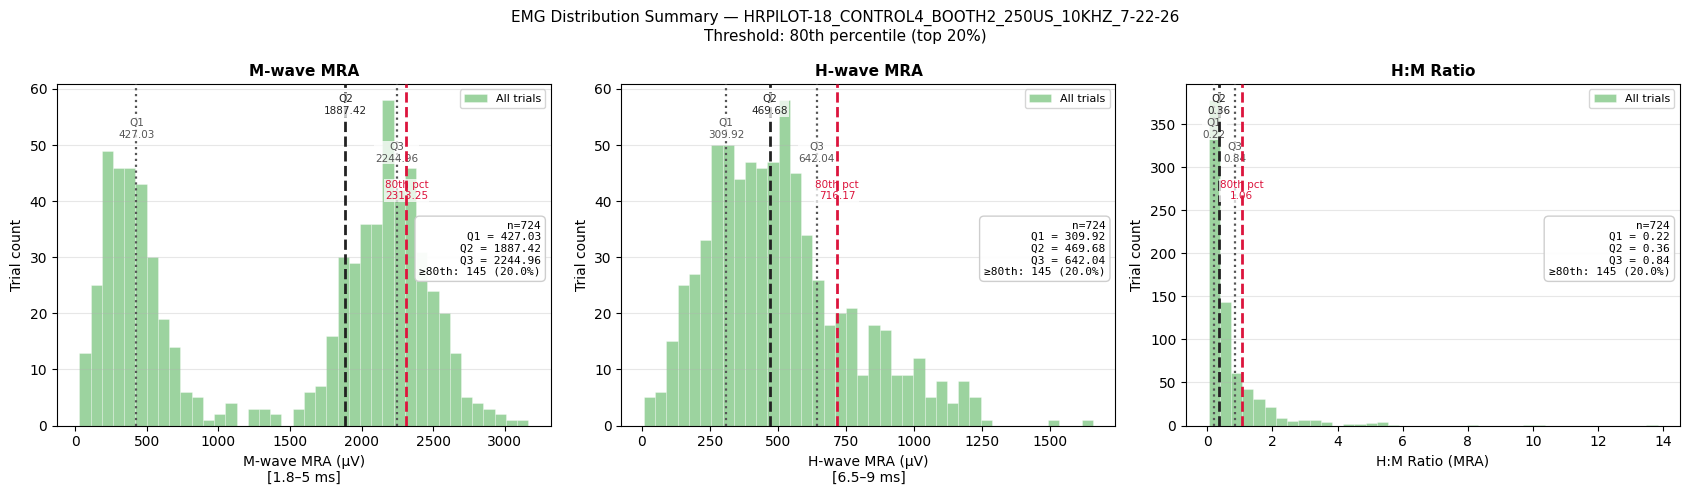

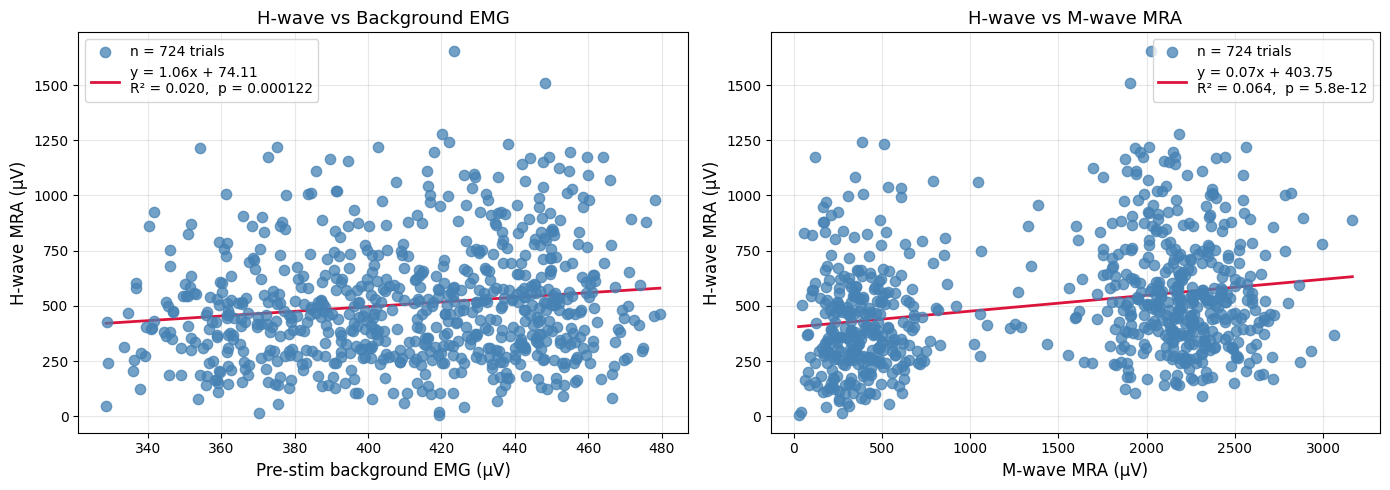

  Regression (n=724):  slope=1.0550  intercept=74.11  R²=0.0202  p=0.0001223


In [15]:
# â”€â”€ Stim Polarity Analysis â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

_pol_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_pol_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    print(f'\nâ”€â”€ Polarity / H:M Ratio: {_slbl}  ({len(_st)} trials)')
    trials_by_polarity = split_trials_by_polarity(_st)
    plot_hm_ratio_summary(
        trials_by_polarity, _sh,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
    )
    plot_hwave_regression(
        _st, _se,
        m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
        h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
        sample_rate=recording_sample_rate or hrs1_header.sample_rate,
        pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
    )
else:
    _pol_out  = Output()
    _pol_drop = Dropdown(options=_pol_opts, description='Stage:', layout={'width': '440px'})
    def _pol_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_pol_drop.value]
        with _pol_out:
            _pol_out.clear_output(wait=True)
            print(f'\nâ”€â”€ Polarity / H:M Ratio: {_slbl}  ({len(_st)} trials)')
            trials_by_polarity = split_trials_by_polarity(_st)
            plot_hm_ratio_summary(
                trials_by_polarity, _sh,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
            )
            plot_hwave_regression(
                _st, _se,
                m_start_ms=M_WAVE_START_MS, m_end_ms=M_WAVE_END_MS,
                h_start_ms=H_WAVE_START_MS, h_end_ms=H_WAVE_END_MS,
                sample_rate=recording_sample_rate or hrs1_header.sample_rate,
                pre_ms=PRE_PLOT_MS, post_ms=POST_PLOT_MS,
            )
    _pol_drop.observe(_pol_show, names='value')
    _disp(VBox([_pol_drop, _pol_out]))
    _pol_show()


# Section 3d: M-Wave Stabilization Control Error (V3)

Trial-by-trial plot of the M-wave stabilization controller output.
- **Left axis** — `m_wave_error` (µV); falls back to `m_wave_window_median` when controller inactive.
- **Right axis** — `stimulation_amplitude_ma` (mA, orange).

Requires V3 recordings (S2 file_version ≥ 9; S4/S5/S6 file_version ≥ 2).

In [16]:
# ── M-Wave Control Error (V3 stages with closed-loop M-wave stabilization) ─
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp
import numpy as np

_mw_stages = {k: v for k, v in _stage_map.items()
              if v[0] and any(not (getattr(t, 'm_wave_error', float('nan')) != getattr(t, 'm_wave_error', float('nan')))
                              or not (getattr(t, 'm_wave_window_median', float('nan')) != getattr(t, 'm_wave_window_median', float('nan')))
                              for t in v[0])}

if not _mw_stages:
    print("No M-wave stabilization data available in any loaded stage "
          "(requires V3 S2 file_version ≥ 9, or S4/S5/S6 file_version ≥ 2).")
else:
    _mw_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _mw_stages.items()]
    if len(_mw_opts) == 1:
        _sk, (_st, _sh, _se, _slbl) = next(iter(_mw_stages.items()))
        print(f'\n── M-Wave Control Error: {_slbl}  ({len(_st)} trials)')
        plot_mwave_control_error(_st, _sh)
    else:
        _mw_out  = Output()
        _mw_drop = Dropdown(options=_mw_opts, description='Stage:', layout={'width': '440px'})
        def _mw_show(change=None):
            _st, _sh, _se, _slbl = _mw_stages[_mw_drop.value]
            with _mw_out:
                _mw_out.clear_output(wait=True)
                print(f'\n── M-Wave Control Error: {_slbl}  ({len(_st)} trials)')
                plot_mwave_control_error(_st, _sh)
        _mw_drop.observe(_mw_show, names='value')
        _disp(VBox([_mw_drop, _mw_out]))
        _mw_show()


── M-Wave Control Error: Control Mode (.hrs2)  (724 trials)


# Section 3e: Frequency Test Analysis (V3 FT)

Per-pulse H-wave and M-wave MRA (mean ± std across trials), showing homosynaptic depression across a stimulus train.

In [17]:
# ── Frequency Test Analysis (V3 FT stage) ─────────────────────────────────
if ft_trials:
    print(f"Frequency Test: {len(ft_trials)} trials  |  "
          f"{getattr(ft_header, 'n_pulses_per_train', '?')} pulses/train  |  "
          f"{round(1e6 / ft_header.event_period_us, 1) if getattr(ft_header, 'event_period_us', 0) else '?'} Hz")
    plot_frequency_test(ft_trials, ft_header)
else:
    print("No Frequency Test data loaded (.hrsft file not found in recording directory).")

No Frequency Test data loaded (.hrsft file not found in recording directory).



── Averaged Waveforms: Control Mode (.hrs2)  (724 trials)


C:\Users\dal866445\AppData\Local\Temp\ipykernel_48044\2228503135.py:68: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


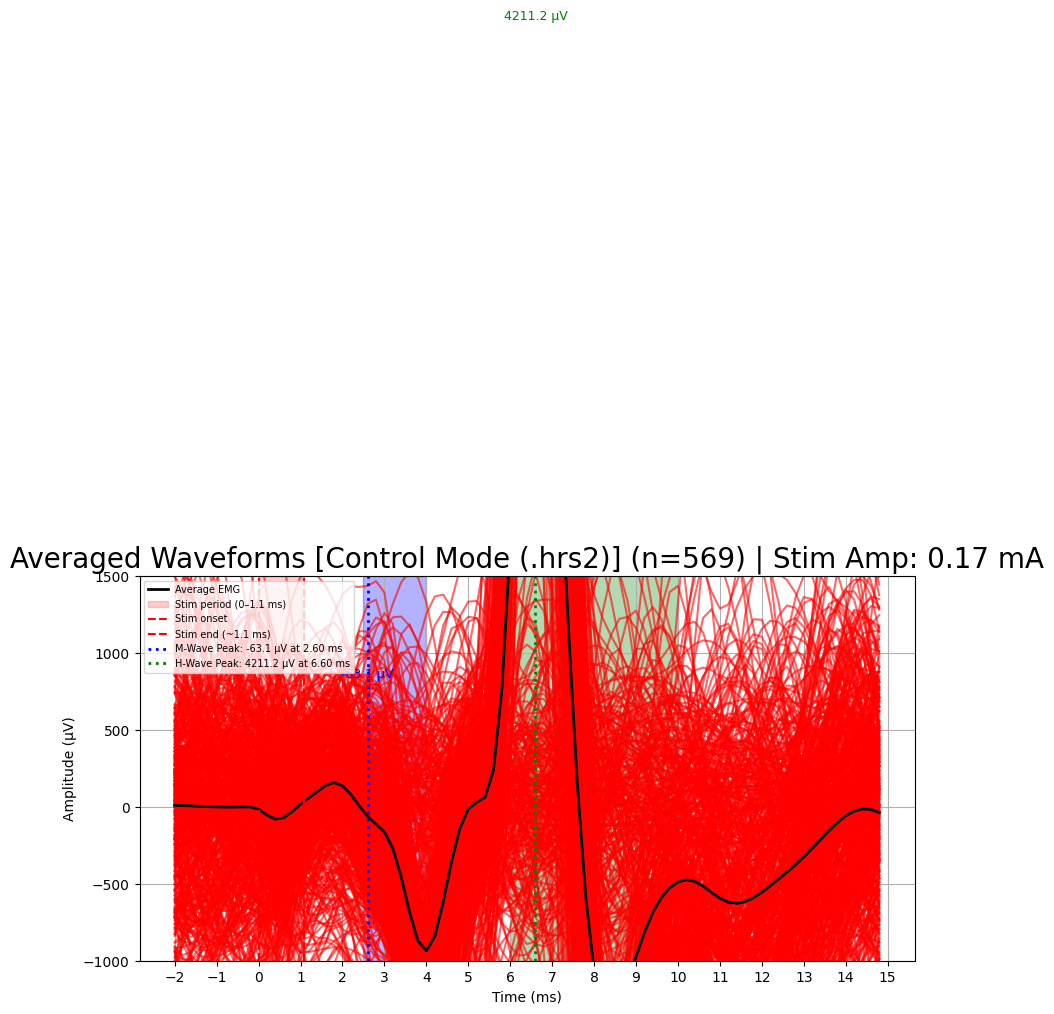

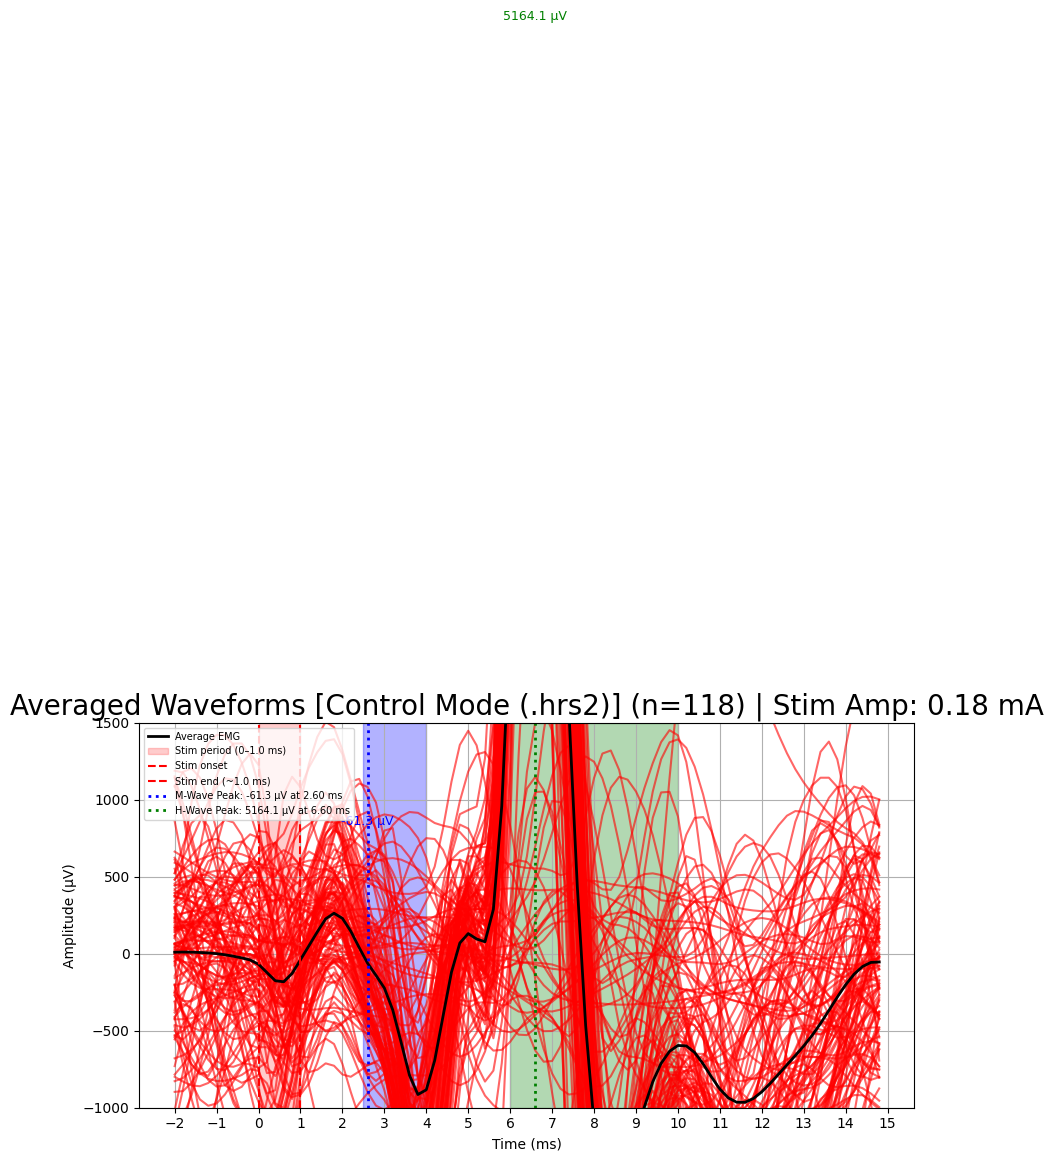

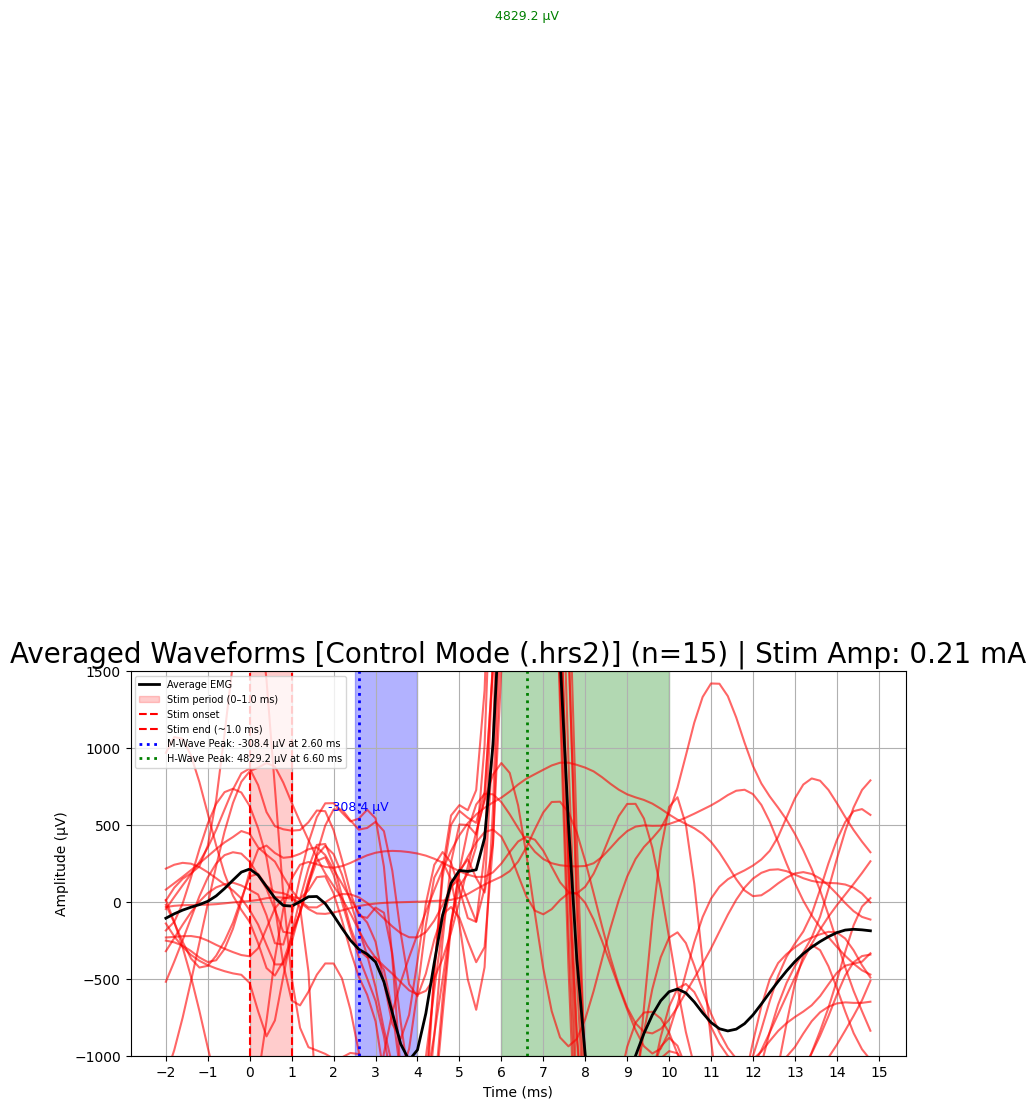

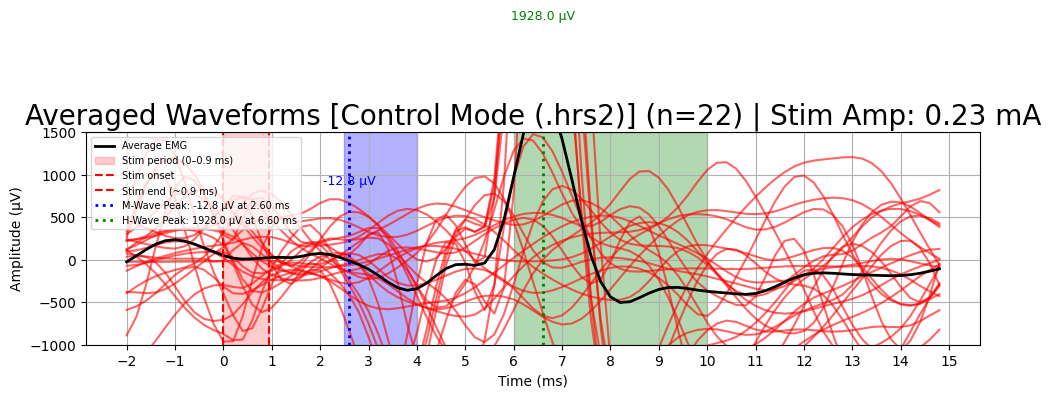

In [18]:
# ── Averaged Waveforms Grouped by Stimulation Amplitude ──────────────────────
from collections import defaultdict
from ipywidgets import Dropdown, VBox, Output
from IPython.display import display as _disp

PRE_AVG_MS  = 2   # ms before stim onset
POST_AVG_MS = 15  # ms after  stim onset
M_WAVE_START_MS_AVG = 2.5
M_WAVE_END_MS_AVG   = 4.0
H_WAVE_START_MS_AVG = 6.0
H_WAVE_END_MS_AVG   = 10.0

def _plot_avg_waveforms(_st, _se, _slbl):
    print(f'\n── Averaged Waveforms: {_slbl}  ({len(_st)} trials)')
    groups = defaultdict(list)
    for trial in _st:
        key = round(trial.stimulation_amplitude_ma, 2)
        t_ms_win, emg_win, _, stim_end, _ = get_trial_window(trial, PRE_AVG_MS, POST_AVG_MS)
        groups[key].append((t_ms_win, emg_win, stim_end))
    _all_emg = np.concatenate([emg for windows in groups.values() for _, emg, _ in windows])
    _lo, _hi = float(np.nanmin(_all_emg)), float(np.nanmax(_all_emg))
    _pad = max(0.08 * (_hi - _lo), 1.0)
    shared_ylim = (_lo - _pad, _hi + _pad)
    _text_offset = 0.05 * (shared_ylim[1] - shared_ylim[0])
    for amp in sorted(groups.keys()):
        windows = groups[amp]
        t_ref = windows[0][0]
        n_pts = len(t_ref)
        padded = np.full((len(windows), n_pts), np.nan)
        for k, (_, emg, _se2) in enumerate(windows):
            n = min(len(emg), n_pts)
            padded[k, :n] = emg[:n]
        avg = np.nanmean(padded, axis=0)
        stim_ends = [se for _, _, se in windows if se is not None]
        mean_stim_end = float(np.mean(stim_ends)) if stim_ends else 0.5
        plt.figure(figsize=(10, 5))
        for row in padded:
            plt.plot(t_ref, row, color='red', alpha=0.6)
        plt.plot(t_ref, avg, color='black', linewidth=2, label='Average EMG')
        plt.axvspan(0, mean_stim_end, color='red', alpha=0.20,
                    label=f'Stim period (0–{mean_stim_end:.1f} ms)')
        plt.axvline(x=0, color='red', linestyle='--', label='Stim onset')
        plt.axvline(x=mean_stim_end, color='red', linestyle='--',
                    label=f'Stim end (~{mean_stim_end:.1f} ms)')
        plt.axvspan(M_WAVE_START_MS_AVG, M_WAVE_END_MS_AVG, color='blue',  alpha=0.3)
        plt.axvspan(H_WAVE_START_MS_AVG, H_WAVE_END_MS_AVG, color='green', alpha=0.3)
        m_mask = (t_ref >= M_WAVE_START_MS_AVG) & (t_ref <= M_WAVE_END_MS_AVG)
        m_t, m_emg = t_ref[m_mask], avg[m_mask]
        m_pi = np.argmax(m_emg)
        h_mask = (t_ref >= H_WAVE_START_MS_AVG) & (t_ref <= H_WAVE_END_MS_AVG)
        h_t, h_emg = t_ref[h_mask], avg[h_mask]
        h_pi = np.argmax(h_emg)
        plt.axvline(x=m_t[m_pi], color='blue', linestyle=':', linewidth=2,
                    label=f'M-Wave Peak: {m_emg[m_pi]:.1f} µV at {m_t[m_pi]:.2f} ms')
        plt.axvline(x=h_t[h_pi], color='green', linestyle=':', linewidth=2,
                    label=f'H-Wave Peak: {h_emg[h_pi]:.1f} µV at {h_t[h_pi]:.2f} ms')
        plt.text(m_t[m_pi], m_emg[m_pi] + _text_offset, f'{m_emg[m_pi]:.1f} µV',
                 color='blue', fontsize=9, ha='center')
        plt.text(h_t[h_pi], h_emg[h_pi] + _text_offset, f'{h_emg[h_pi]:.1f} µV',
                 color='green', fontsize=9, ha='center')
        plt.title(f'Averaged Waveforms [{_slbl}] (n={len(windows)}) | Stim Amp: {amp:.2f} mA', fontsize=20)
        plt.xlabel('Time (ms)')
        plt.ylabel('Amplitude (µV)')
        plt.grid(True)
        plt.legend(fontsize=7, loc='upper left', frameon=True, framealpha=0.8)
        plt.ylim(-1000, 1500)
        plt.xticks(np.arange(int(np.floor(t_ref[0])), int(np.ceil(t_ref[-1])) + 1, 1))
        plt.tight_layout()
        plt.show()

_avg_opts = [(lbl, sk) for sk, (_t, _h, _e, lbl) in _stage_map.items() if _t]
if len(_avg_opts) == 1:
    _sk, (_st, _sh, _se, _slbl) = next(iter(_stage_map.items()))
    _plot_avg_waveforms(_st, _se, _slbl)
else:
    _avg_out  = Output()
    _avg_drop = Dropdown(options=_avg_opts, description='Stage:', layout={'width': '440px'})
    def _avg_show(change=None):
        _st, _sh, _se, _slbl = _stage_map[_avg_drop.value]
        with _avg_out:
            _avg_out.clear_output(wait=True)
            _plot_avg_waveforms(_st, _se, _slbl)
    _avg_drop.observe(_avg_show, names='value')
    _disp(VBox([_avg_drop, _avg_out]))
    _avg_show()